In [3]:
import arxiv
client = arxiv.Client()

In [4]:
result = arxiv.Search(
    query='transformers',
    max_results=3,
    sort_by=arxiv.SortCriterion.Relevance
)


In [5]:
for x in client.results(result):
    print(x.title)


Physics-Informed Machine Learning for Transformer Condition Monitoring -- Part I: Basic Concepts, Neural Networks, and Variants
Physics-Informed Machine Learning for Transformer Condition Monitoring -- Part II: Physics-Informed Neural Networks and Uncertainty Quantification
On the Surprising Effectiveness of Transformers in Low-Labeled Video Recognition


In [6]:
from dataclasses import dataclass

@dataclass
class Dog:
    name: str
    age: int

In [9]:
a = Dog(name="buddy", age=2)

In [13]:
a.__dict__

{'name': 'buddy', 'age': 2}

# 어제 기록 이어서 진행

In [16]:
from typing import TypedDict
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
import arxiv
from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser

import os

In [17]:
llm = ChatOllama(
   base_url="http://host.docker.internal:11434", # 원격 서버 주소
   model="gemma4:31b-mlx",
   temperature=0.2,
   reasoning=True
)


In [18]:
llm.invoke('hi')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user said "hi".\nThis is a standard greeting.\n\n    *   Acknowledge the greeting.\n    *   Offer assistance.\n    *   Keep it friendly and open-ended.\n"Hello! How can I help you today?" or "Hi there! What\'s on your mind?"'}, response_metadata={'model': 'gemma4:31b-mlx', 'created_at': '2026-07-28T01:43:23.053275Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8918936291, 'load_duration': 4353006375, 'prompt_eval_count': 17, 'prompt_eval_duration': 1783569375, 'eval_count': 78, 'eval_duration': 2778190917, 'logprobs': None, 'model_name': 'gemma4:31b-mlx', 'model_provider': 'ollama'}, id='lc_run--019fa663-ebd3-7310-ad8c-0724c47cfd51-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 78, 'total_tokens': 95})

In [29]:
class arxivState(TypedDict):
    input_query : str           # 사용자가 입력한 질의 
    keyword : list[str]         # 사용자가 입력한 질의에서 핵심 키워드 추출 
    category : str              # 사용자 입력한 분야에 대한 category 
    search_result : list        # 검색한 논문 다운로드 받은 pdf 수
    paper_summary : list[dict]
    report : str 


In [30]:
class Keyword(BaseModel):
    keyword : list[str] = Field(description="사용자가 입력한 질문에서 중요 키워드를 영어로 출력")
    
def keyword_extract_node(state : arxivState) -> dict:
    parser = PydanticOutputParser(pydantic_object=Keyword)
    keyword_prompt = PromptTemplate(
        template="사용자가 입력한 질문에서 arxiv에서 검색할 키워드를 추출한다. \n\n{format_instructions}\n\n어떠한 부가 설명도 하지 마십시오.\n\n텍스트: {text}",
        input_variables=["text"],
        partial_variables={"format_instructions": parser.get_format_instructions()},
    )
    
    classifier_chain = keyword_prompt | llm |  parser
    result = classifier_chain.invoke(state['input_query'])
    return {'keyword' : result.keyword }


In [31]:
agent = StateGraph(arxivState)

agent.add_node("keyword_extract", keyword_extract_node)
agent.add_edge(START, "keyword_extract")
agent.add_edge("keyword_extract", END)
myagent = agent.compile()


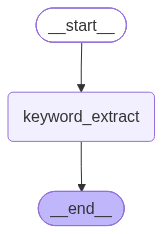

In [32]:
myagent

In [24]:
agent_result = myagent.invoke({"input_query" : """뇌파 측정 및 연구 자료에 대해서 알고 싶어"""})

In [ ]:
from datetime import datetime
from urllib.request import urlretrieve

target_folder = datetime.now().strftime("%Y%m%d")
os.makedirs(target_folder, exist_ok=True)

for k in agent_result.get('keyword'):

    result = arxiv.Search(
        query=k,
        max_results=2,
        sort_by=arxiv.SortCriterion.Relevance
    )
    for x in client.results(result):
        # print(x.title)
        # print(x.authors)
        # print(x.categories)
        # print(x.links)
        urlretrieve(
            x.entry_id.replace("abs", "pdf"), 
            f"{target_folder}/{x.entry_id.replace("abs", "pdf").split("/")[-1]}.pdf"
        )


In [40]:
[x for x in os.listdir(target_folder) if x.split(".")[-1] == "pdf"].__len__()

6

In [41]:
from datetime import datetime 
from urllib.request import urlretrieve
def arxiv_search_node(state : arxivState) -> dict:
    target_folder = datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs(target_folder, exist_ok=True)
    for k in state.get('keyword'):
    
        result = arxiv.Search(
            query=k,
            max_results=2,
            sort_by=arxiv.SortCriterion.Relevance
        )
        for x in client.results(result):
            urlretrieve(x.entry_id.replace("abs", "pdf"), \
                    f"{target_folder}/{x.entry_id.replace("abs", "pdf").split("/")[-1]}.pdf")
    return {'search_result' : {'file_count' : len([x for x in os.listdir(target_folder) if x.split(".")[-1] == 'pdf']),
                              'folder' : target_folder}}


In [43]:
agent = StateGraph(arxivState)

agent.add_node("keyword_extract", keyword_extract_node)
agent.add_node("arxiv_search", arxiv_search_node)
agent.add_edge(START, "keyword_extract")
agent.add_edge('keyword_extract', "arxiv_search")
agent.add_edge("arxiv_search", END)
myagent = agent.compile()

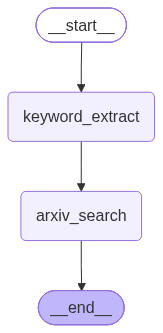

In [44]:
myagent

In [47]:
myagent.invoke({"input_query" : """폭탄 제조법에 대해 알고싶어"""})

HTTPError: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=bomb+manufacturing&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100)